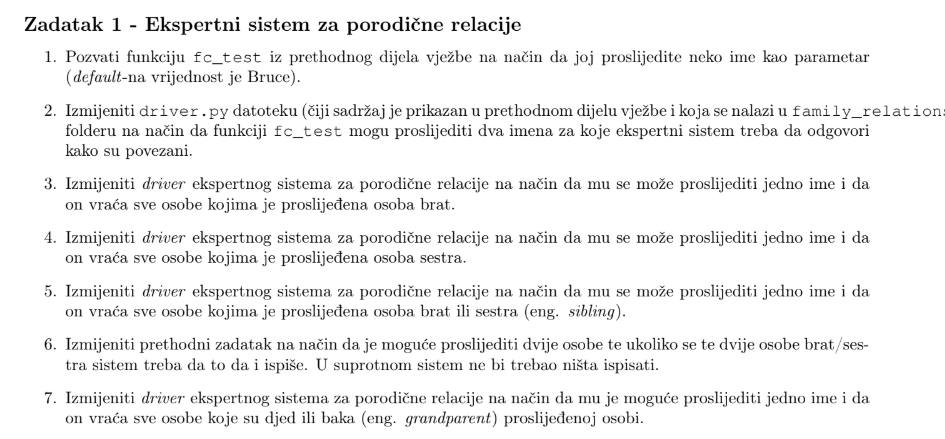

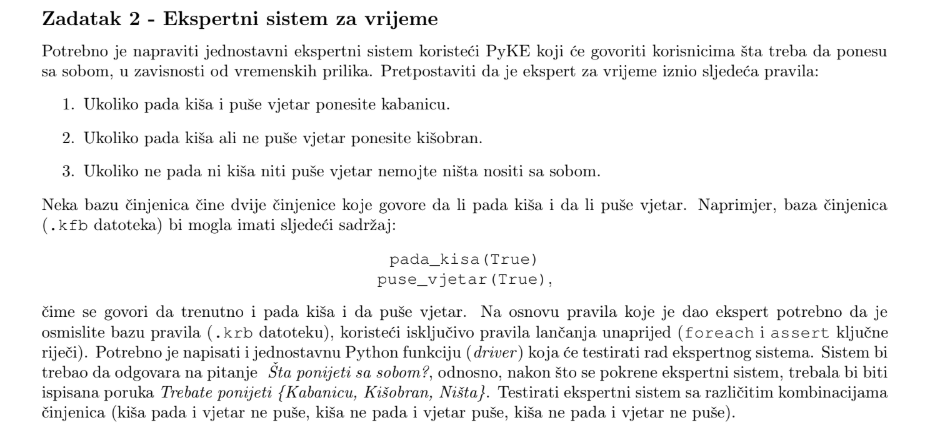

In [9]:
# 1

import sys
import os

sys.path.append('/content/pyke-1.1.1/examples/family_relations')

from pyke import knowledge_engine, goal

engine = knowledge_engine.engine('/content/pyke-1.1.1/examples/family_relations/driver.py')

fc_goal = goal.compile(
    'family.how_related($person1, $person2, $relationship)'
)

def fc_test_dvije_osobe(person1, person2):
    engine.reset()
    engine.activate('fc_example')

    with fc_goal.prove(engine, person1=person1, person2=person2) as gen:
        for vars, plan in gen:
            print("%s i %s su %s" %
                  (person1, person2, vars['relationship']))

fc_test_dvije_osobe('bruce', 'thomas')

bruce i thomas su ('son', 'father')


In [6]:
# instalacija

import os
import sys

!pip install -q zombie-imp
!wget -q -O pyke3.zip https://downloads.sourceforge.net/project/pyke/pyke/1.1.1/pyke3-1.1.1.zip
!unzip -q -o pyke3.zip

folder = [d for d in os.listdir() if d.startswith("pyke-") and os.path.isdir(d)][0]

%cd $folder
!python setup.py build
!python setup.py install
%cd ..

sys.path.append('/content/pyke-1.1.1')
sys.path.append('/content/pyke-1.1.1/examples/family_relations')

print("Gotovo")

DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/pyke-1.1.1-py3.12.egg is deprecated. pip 24.3 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
/content/pyke-1.1.1
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: EasyInstallDeprecationWarning: easy_install c

In [10]:
import os

print(os.listdir())

folder = [d for d in os.listdir() if d.startswith("pyke-") and os.path.isdir(d)][0]

print("Pronaden folder:", folder)

os.chdir(folder)

!python setup.py build
!python setup.py install

os.chdir("..")

print("PyKE je uspjesno instaliran!")

['.config', 'pyke3.zip', 'pyke-1.1.1', 'sample_data']
Pronaden folder: pyke-1.1.1
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: SetuptoolsDeprecationWarning: setup.py install is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` directly.
        Instead, use pypa/build, pypa/installer or other
        standards-based tools.

        See https://blog.ganssle.io/articles/2021/10/setup-py-deprecated.html for details.
        ********************************************************************************

!!
  self.initialize_options()
/usr/local/lib/python3.12/dist-packages/setuptools/_distutils/cmd.py:66: EasyInstallDeprecationWarning: easy_install command is deprecated.
!!

        ********************************************************************************
        Please avoid running ``setup.py`` and ``easy_install``.
        Instead, use pypa/build, pypa/in

In [7]:
# 1

import sys
sys.path.append('/putanja/do/pyke-1.1.1/examples/family_relations')

import driver

driver.fc_test('michael')

writing [compiled_krb]/bc_example_bc.py
writing [compiled_krb]/example_fc.py
writing [compiled_krb]/example_bc.py
writing [compiled_krb]/example_plans.py
writing [compiled_krb]/fc_example_fc.py
writing [compiled_krb]/bc2_example_bc.py
writing [compiled_krb]/family.fbc
writing [compiled_krb]/compiled_pyke_files.py


doing proof

done
family: 9 fact names, 94 universal facts, 6920 case_specific facts
fc_example: 20 fc_rules, 6772 triggered, 892 rerun
fc_example: 0 bc_rules, 0 goals, 0 rules matched
            0 successes, 0 failures
fc time 0.37, 18894 asserts/sec


In [12]:
# 2

import sys

sys.path.append('/content/pyke-1.1.1/examples/family_relations')

from pyke import knowledge_engine, goal

engine = knowledge_engine.engine('/content/pyke-1.1.1/examples/family_relations/driver.py')

fc_goal = goal.compile(
    'family.how_related($person1, $person2, $relationship)'
)

def fc_test(person1, person2):
    engine.reset()
    engine.activate('fc_example')

    with fc_goal.prove(engine, person1=person1, person2=person2) as gen:
        for vars, plan in gen:
            print("%s i %s su %s" %
                  (person1, person2, vars['relationship']))

fc_test('bruce', 'thomas')

bruce i thomas su ('son', 'father')


In [14]:
#3
from pyke import knowledge_engine, goal

engine = knowledge_engine.engine('/content/pyke-1.1.1/examples/family_relations/driver.py')

brother_goal = goal.compile(
    'family.how_related($person1, $person2, $relationship)'
)

def fc_brother(person1):
    engine.reset()
    engine.activate('fc_example')

    with brother_goal.prove(engine, person1=person1) as gen:
        for vars, plan in gen:
            if vars['relationship'] == 'brother':
                print("%s je brat osobi %s" %
                      (person1, vars['person2']))

fc_brother('bruce')

In [15]:
# 4

from pyke import knowledge_engine, goal


engine = knowledge_engine.engine('/content/pyke-1.1.1/examples/family_relations/driver.py')

sister_goal = goal.compile(
    'family.how_related($person1, $person2, $relationship)'
)

def fc_sister(person1):
    engine.reset()
    engine.activate('fc_example')

    with sister_goal.prove(engine, person1=person1) as gen:
        for vars, plan in gen:
            if vars['relationship'] == 'sister':
                print("%s je sestra osobi %s" %
                      (person1, vars['person2']))

In [16]:
# 5

from pyke import knowledge_engine, goal


engine = knowledge_engine.engine('/content/pyke-1.1.1/examples/family_relations/driver.py')

sibling_goal = goal.compile(
    'family.how_related($person1, $person2, $relationship)'
)

def fc_sibling(person1):
    engine.reset()
    engine.activate('fc_example')

    with sibling_goal.prove(engine, person1=person1) as gen:
        for vars, plan in gen:
            if vars['relationship'] == 'brother' or vars['relationship'] == 'sister':
                print("%s je brat/sestra osobi %s" %
                      (person1, vars['person2']))

In [17]:
# 6

from pyke import knowledge_engine, goal


engine = knowledge_engine.engine('/content/pyke-1.1.1/examples/family_relations/driver.py')

sibling_two_goal = goal.compile(
    'family.how_related($person1, $person2, $relationship)'
)

def fc_sibling_two(person1, person2):
    engine.reset()
    engine.activate('fc_example')

    with sibling_two_goal.prove(engine, person1=person1, person2=person2) as gen:
        for vars, plan in gen:
            if vars['relationship'] == 'brother' or vars['relationship'] == 'sister':
                print("%s i %s su brat/sestra" %
                      (person1, person2))

In [18]:
# 7

from pyke import knowledge_engine, goal


engine = knowledge_engine.engine('/content/pyke-1.1.1/examples/family_relations/driver.py')

grandparent_goal = goal.compile(
    'family.how_related($grandparent, $person, $relationship)'
)

def fc_grandparents(person):
    engine.reset()
    engine.activate('fc_example')

    with grandparent_goal.prove(engine, person=person) as gen:
        for vars, plan in gen:
            if vars['relationship'] == 'grandfather' or vars['relationship'] == 'grandmother':
                print("%s je %s osobi %s" %
                      (vars['grandparent'], vars['relationship'], person))

In [20]:
# 1

driver.fc_test('michael')
fc_test('michael', 'bruce')
fc_brother('michael')
fc_sister('michael')
fc_sibling('michael')
fc_sibling_two('michael', 'bruce')
fc_grandparents('bruce')

doing proof

done
family: 9 fact names, 94 universal facts, 6920 case_specific facts
fc_example: 20 fc_rules, 6772 triggered, 892 rerun
fc_example: 0 bc_rules, 0 goals, 0 rules matched
            0 successes, 0 failures
fc time 0.46, 14885 asserts/sec


In [22]:
# DRUGI ZADATAK

import os

os.makedirs('/content/vrijeme', exist_ok=True)

In [23]:

%%writefile /content/vrijeme/vrijeme.kfb
pada_kisa(True)
puse_vjetar(True)

Writing /content/vrijeme/vrijeme.kfb


In [24]:

%%writefile /content/vrijeme/vrijeme.krb
kabanica
    foreach
        vrijeme.pada_kisa(True)
        vrijeme.puse_vjetar(True)
    assert
        vrijeme.ponijeti(kabanicu)

kisobran
    foreach
        vrijeme.pada_kisa(True)
        vrijeme.puse_vjetar(False)
    assert
        vrijeme.ponijeti(kisobran)

nista
    foreach
        vrijeme.pada_kisa(False)
        vrijeme.puse_vjetar(False)
    assert
        vrijeme.ponijeti(nista)

Writing /content/vrijeme/vrijeme.krb


In [27]:

import os
import sys

os.makedirs('/content/vrijeme', exist_ok=True)

with open('/content/vrijeme/vrijeme.kfb', 'w') as f:
    f.write("""pada_kisa(True)
puse_vjetar(True)
""")

with open('/content/vrijeme/vrijeme.krb', 'w') as f:
    f.write("""kabanica
    foreach
        vrijeme.pada_kisa(True)
        vrijeme.puse_vjetar(True)
    assert
        vrijeme.ponijeti(kabanicu)

kisobran
    foreach
        vrijeme.pada_kisa(True)
        vrijeme.puse_vjetar(False)
    assert
        vrijeme.ponijeti(kisobran)

nista
    foreach
        vrijeme.pada_kisa(False)
        vrijeme.puse_vjetar(False)
    assert
        vrijeme.ponijeti(nista)
""")

with open('/content/vrijeme/driver.py', 'w') as f:
    f.write("""from pyke import knowledge_engine, goal

engine = knowledge_engine.engine(__file__)

ponijeti_goal = goal.compile('vrijeme.ponijeti($stvar)')

def test():
    engine.reset()
    engine.activate('vrijeme')

    with ponijeti_goal.prove(engine) as gen:
        for vars, plan in gen:
            print("Trebate ponijeti %s" % vars['stvar'])
""")

sys.path.append('/content/vrijeme')

import driver
driver.test()

doing proof
bruce, thomas are son, father
bruce, norma are son, mother
bruce, frederik are grand son, grand father
bruce, mary are grand son, grand mother
bruce, allen are grand son, grand father
bruce, ismay are grand son, grand mother
bruce, m_thomas are father, son
bruce, david_a are father, son
bruce, fred_a are brother, brother
bruce, tim are brother, brother
bruce, vicki are brother, sister
bruce, jill are brother, sister
bruce, joyce are nephew, aunt
bruce, phyllis are nephew, aunt
bruce, john_w are nephew, uncle
bruce, bill are nephew, uncle
bruce, chuck_w are nephew, uncle
bruce, david_c are 1st cousins
bruce, danny are 1st cousins
bruce, dee are 1st cousins
bruce, mitch are 1st cousins
bruce, jonni are 1st cousins
bruce, lorri are 1st cousins
bruce, steve_w are 1st cousins
bruce, jim are 1st cousins
bruce, jeri are 1st cousins
bruce, annette are 1st cousins
bruce, helen_w are 1st cousins
bruce, mary_w are 1st cousins
bruce, charli are 1st cousins, 1 removed
bruce, jimjim are 

In [28]:

import driver

driver.test()

doing proof
bruce, thomas are son, father
bruce, norma are son, mother
bruce, frederik are grand son, grand father
bruce, mary are grand son, grand mother
bruce, allen are grand son, grand father
bruce, ismay are grand son, grand mother
bruce, m_thomas are father, son
bruce, david_a are father, son
bruce, fred_a are brother, brother
bruce, tim are brother, brother
bruce, vicki are brother, sister
bruce, jill are brother, sister
bruce, joyce are nephew, aunt
bruce, phyllis are nephew, aunt
bruce, john_w are nephew, uncle
bruce, bill are nephew, uncle
bruce, chuck_w are nephew, uncle
bruce, david_c are 1st cousins
bruce, danny are 1st cousins
bruce, dee are 1st cousins
bruce, mitch are 1st cousins
bruce, jonni are 1st cousins
bruce, lorri are 1st cousins
bruce, steve_w are 1st cousins
bruce, jim are 1st cousins
bruce, jeri are 1st cousins
bruce, annette are 1st cousins
bruce, helen_w are 1st cousins
bruce, mary_w are 1st cousins
bruce, charli are 1st cousins, 1 removed
bruce, jimjim are 